# Project: Investigate a Medical Appointments Attendance

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
<li><a href="#recommendations">Recommendations</a></li>
</ul>

<a i='intro'></a>
## Introduction
### Medical Appointments Attendance Analysis Report

#### 1. Dataset Introduction
In this report, we analyze a comprehensive medical appointment dataset to understand the key factors influencing patient attendance. The dataset records various patient demographics, medical history flags (such as hypertension, diabetes, and alcoholism), neighborhood locations, and whether they received an SMS reminder. The primary goal is to uncover patterns and actionable insights that help healthcare providers minimize missed appointments (no-shows).

#### 2. Dependent and Independent Variables
To drive our analysis, the report is structured around one core dependent variable and multiple independent variables:
* **Dependent Variable:** 
  * `Absent` (Patient attendance status / No-show).
* **Independent Variables:**
  * `Age / Age_Group` (Patient age and categorizations: Young, Adult, Old).
  * `Has_Chronic` (Presence of chronic conditions or disabilities).
  * `SMS_received` (Whether an SMS reminder was received).
  * `Neighbourhood` (The residential area or district of the patient).

#### 3. Research Questions
Throughout this report, we aim to answer the following analytical questions based on our data exploration and visualizations:
1. How many absent patient for each gender (No-shows)?
2. Does neighborhood influence the rate of missed appointments?
3. Do patients enrolled in Scholarship show up more often than those who are not?
4. How effective are SMS reminders (SMS_received) in reducing patient absent?
5. Do chronic conditions make patients more compliant with their hospital appointments?
6. How does the patient's age group relate to the likelihood of skipping an appointment?

<a id='wrangling'></a>
## Data Wrangling
### General Properties

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
medical_data = pd.read_csv(r'..\RawData\KaggleV2-May-2016.csv')

medical_data.head(5)

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [2]:
medical_data.sample(5)

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
99063,2.616945e+14,5775166,F,2016-06-06T09:08:08Z,2016-06-06T00:00:00Z,11,DA PENHA,0,0,0,0,0,0,No
52183,2.441190e+11,5674744,F,2016-05-09T11:48:41Z,2016-05-11T00:00:00Z,84,CRUZAMENTO,0,1,0,0,0,0,No
149,2.147153e+12,5641472,F,2016-04-29T13:43:19Z,2016-04-29T00:00:00Z,16,ITARARÉ,0,0,0,0,0,0,No
41853,5.728456e+12,5613066,F,2016-04-25T08:59:14Z,2016-05-10T00:00:00Z,54,JARDIM DA PENHA,0,0,0,0,0,1,No
69724,8.538941e+12,5700761,F,2016-05-16T09:45:27Z,2016-05-16T00:00:00Z,57,PRAIA DO CANTO,0,0,0,0,0,0,No


In [3]:
medical_data.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [4]:
medical_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  str    
 3   ScheduledDay    110527 non-null  str    
 4   AppointmentDay  110527 non-null  str    
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  str    
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  str    
dtypes: float64(1), int64(8), str(5)
memory usage: 11.8 MB


Check Duplicated Values

In [5]:
medical_data.duplicated().sum()

np.int64(0)

Check Null Values

In [6]:
medical_data.isna().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

### Data Cleaning 

Let's check if People has age 0 or less so that's not possible 

In [7]:
medical_data['PatientId'][medical_data['Age'] <= 0].count()    #  3540 all that people with age 0 or less!!

np.int64(3540)

Removing Data for Peaple with age 0 or negative 

In [8]:
medical_data.drop(medical_data[medical_data['Age'] <= 0].index , inplace=True)

medical_data['PatientId'][medical_data['Age'] <= 0].count()

np.int64(0)

In [9]:
medical_data.nunique()  #Count unique values in each column

PatientId          60270
AppointmentID     106987
Gender                 2
ScheduledDay      100307
AppointmentDay        27
Age                  102
Neighbourhood         81
Scholarship            2
Hipertension           2
Diabetes               2
Alcoholism             2
Handcap                5
SMS_received           2
No-show                2
dtype: int64

Gender, Scholarship, Hipertension, Diabetes, Alcoholism, SMS_received :

these are Boolen values 1 or 0 so we going to make them category to save more memory

Handcap : It can be category cause there are only 5 value in all 110527 row

Neighbourhood : It can be category too cause there are 81 value in all 110527 row

the way date must be datetime and we can delete UTC from all dates

In [10]:
medical_data['AppointmentDay'].unique()

<StringArray>
['2016-04-29T00:00:00Z', '2016-05-03T00:00:00Z', '2016-05-10T00:00:00Z',
 '2016-05-17T00:00:00Z', '2016-05-24T00:00:00Z', '2016-05-31T00:00:00Z',
 '2016-05-02T00:00:00Z', '2016-05-30T00:00:00Z', '2016-05-16T00:00:00Z',
 '2016-05-04T00:00:00Z', '2016-05-19T00:00:00Z', '2016-05-12T00:00:00Z',
 '2016-05-06T00:00:00Z', '2016-05-20T00:00:00Z', '2016-05-05T00:00:00Z',
 '2016-05-13T00:00:00Z', '2016-05-09T00:00:00Z', '2016-05-25T00:00:00Z',
 '2016-05-11T00:00:00Z', '2016-05-18T00:00:00Z', '2016-05-14T00:00:00Z',
 '2016-06-02T00:00:00Z', '2016-06-03T00:00:00Z', '2016-06-06T00:00:00Z',
 '2016-06-07T00:00:00Z', '2016-06-01T00:00:00Z', '2016-06-08T00:00:00Z']
Length: 27, dtype: str

Highest Age is 115 so we can make int8 can carry up to 128 is enough

In [11]:
medical_data['Age'].sort_values(ascending=False).head(5)

63912    115
63915    115
97666    115
76284    115
68127    115
Name: Age, dtype: int64

In [12]:
medical_data.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show'],
      dtype='str')

In [13]:
# Change types for some columns to 'Category'
for col in ['Gender', 'Neighbourhood', 'Scholarship', 'Hipertension','Diabetes', 'Alcoholism', 'Handcap', 'SMS_received']:
    medical_data[col] = medical_data[col].astype('category')

In [14]:
# Change types for Date columns to 'Datetime'
for col in ['ScheduledDay','AppointmentDay'] :
    medical_data[col] = pd.to_datetime(medical_data[col]).dt.tz_localize(None)

In [15]:
# Change dtypes for Age columns to 'Int8' 
medical_data['Age'] = medical_data['Age'].astype('Int8') 

In [16]:
medical_data = medical_data.rename(columns={'No-show':'Absent'})   # to be more clear than no-show

medical_data['Absent'] = medical_data['Absent'].map({'Yes': 1, 'No': 0}).astype('Int8') # int to get his mean()*100 as percentage

In [17]:
medical_data['Absent'].unique()

<IntegerArray>
[0, 1]
Length: 2, dtype: Int8

Change F, M to Female, Male to be more clear

In [18]:
medical_data['Gender'] = medical_data['Gender'].str.strip().map({"F": "Female", "M": "Male"})
medical_data['Gender'].unique()


<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [19]:
medical_data.info()  #memory usage went from 11.8 MB to 6.2 MB

<class 'pandas.DataFrame'>
Index: 106987 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   PatientId       106987 non-null  float64       
 1   AppointmentID   106987 non-null  int64         
 2   Gender          106987 non-null  str           
 3   ScheduledDay    106987 non-null  datetime64[us]
 4   AppointmentDay  106987 non-null  datetime64[us]
 5   Age             106987 non-null  Int8          
 6   Neighbourhood   106987 non-null  category      
 7   Scholarship     106987 non-null  category      
 8   Hipertension    106987 non-null  category      
 9   Diabetes        106987 non-null  category      
 10  Alcoholism      106987 non-null  category      
 11  Handcap         106987 non-null  category      
 12  SMS_received    106987 non-null  category      
 13  Absent          106987 non-null  Int8          
dtypes: Int8(2), category(7), datetime64[us](2), float64(

<a id='eda'></a>
## Exploratory Data Analysis


### 1- How many absent patient for each gender (No-shows)?

In [20]:
Absent = medical_data[medical_data['Absent'] == 1]

In [21]:
Gender_Absent = Absent.groupby('Gender')['PatientId'].count().reset_index().rename(columns={'PatientId':'AbsentTotal'})
Gender_Absent

,Gender,AbsentTotal
0,Female,14275
1,Male,7405


### 2- Does neighborhood influence the rate of missed appointments?

In [22]:
Neigh_Absent = Absent.groupby('Neighbourhood')['PatientId'].count().sort_values(ascending=False).reset_index().rename(columns={'PatientId':'AbsentTotal'}).head(10)
Neigh_Absent

,Neighbourhood,AbsentTotal
0,JARDIM CAMBURI,1432
1,MARIA ORTIZ,1194
2,ITARARÉ,898
3,RESISTÊNCIA,875
4,CENTRO,692
5,JESUS DE NAZARETH,676
6,JARDIM DA PENHA,627
7,CARATOÍRA,586
8,TABUAZEIRO,552
9,BONFIM,537


### 3- Do patients enrolled in Scholarship show up more often than those who are not?

In [23]:
Absent['Scholarship'] = Absent['Scholarship'].map({0: 'No', 1: 'Yes'})

Scholar_Absent = Absent.groupby('Scholarship')['PatientId'].count().reset_index().rename(columns={'PatientId':'AbsentTotal'})
Scholar_Absent

,Scholarship,AbsentTotal
0,No,19109
1,Yes,2571


### 4- How effective are SMS reminders (SMS_received) in reducing patient absent?

In [24]:
Absent['SMS_received'] = Absent['SMS_received'].map({0: 'No', 1: 'Yes'})

In [25]:
SMS_Absent = Absent.groupby('SMS_received')['Absent'].count().reset_index().rename(columns={'Absent':'AbsentTotal'})
SMS_Absent

,SMS_received,AbsentTotal
0,No,12112
1,Yes,9568


### 5- Do chronic conditions (such as Hypertension or Diabetes) make patients more compliant with their hospital appointments?

In [26]:
#Adding new column to show if patient has chronic conditions
medical_data['Has_Chronic'] = (
    (medical_data['Hipertension'] == 1) | 
    (medical_data['Diabetes'] == 1) | 
    (medical_data['Alcoholism'] == 1) | 
    (medical_data['Handcap'].isin([1, 2, 3, 4, 5]))   
)


In [27]:
Chronic_Absent = medical_data.groupby('Has_Chronic')['Absent'].mean()*100
Chronic_Absent = Chronic_Absent.reset_index().round(2)
Chronic_Absent

,Has_Chronic,Absent
0,False,21.05
1,True,17.86


### 6- How does the patient's age group relate to the likelihood of skipping an appointment?

In [28]:
bins = [0, 18, 45, 120]  # من 0 لـ 18 أطفال/شباب صغير، ومن 19 لـ 45 بالغين، ومن 46 فما فوق كبار سن
labels = ['Young', 'Adult', 'Old']

# Create Age_Group Column
medical_data['Age_Group'] = pd.cut(medical_data['Age'], bins=bins, labels=labels, right=True)

In [29]:
Age_absent = medical_data.groupby('Age_Group')['Absent'].mean() * 100
Age_absent = Age_absent.reset_index().round(2)
Age_absent

,Age_Group,Absent
0,Young,22.54
1,Adult,22.82
2,Old,16.62


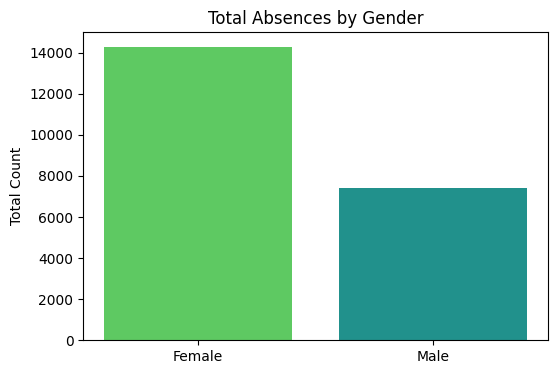

In [37]:
# Total Absences by Gender
plt.figure(figsize=(6, 4))
plt.bar(Gender_Absent.iloc[:, 0].astype(str), Gender_Absent.iloc[:, 1], color=['#5ec962',"#21918c"])
plt.title('Total Absences by Gender')
plt.ylabel('Total Count')
plt.show()

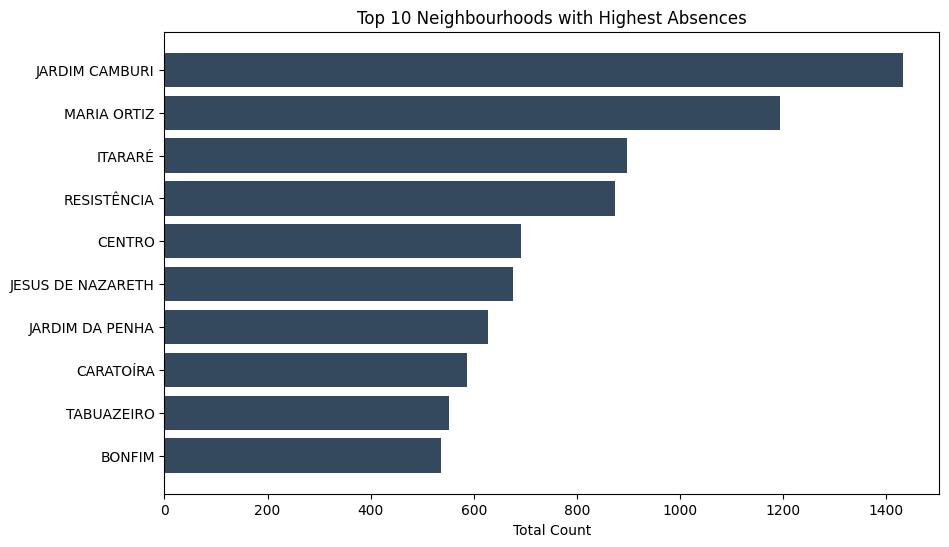

In [31]:
# Top 10 Neighbourhoods with Highest Absences
plt.figure(figsize=(10, 6))
plt.barh(Neigh_Absent.iloc[:, 0].astype(str), Neigh_Absent.iloc[:, 1], color='#34495e')
plt.title('Top 10 Neighbourhoods with Highest Absences')
plt.xlabel('Total Count')
plt.gca().invert_yaxis() # لعكس الترتيب وجعل الأكبر في الأعلى
plt.show()

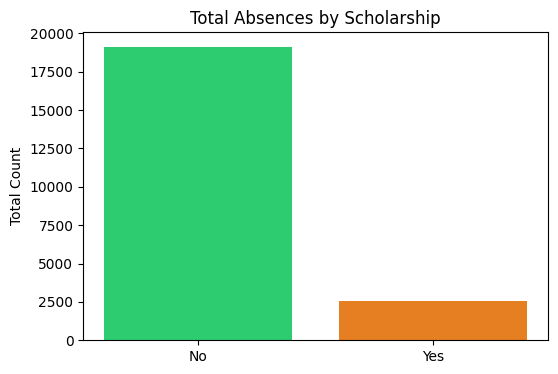

In [32]:
# Total Absences by Scholarship
plt.figure(figsize=(6, 4))
plt.bar(Scholar_Absent.iloc[:, 0].astype(str), Scholar_Absent.iloc[:, 1], color=['#2ecc71', '#e67e22'])
plt.title('Total Absences by Scholarship')
plt.ylabel('Total Count')
plt.show()

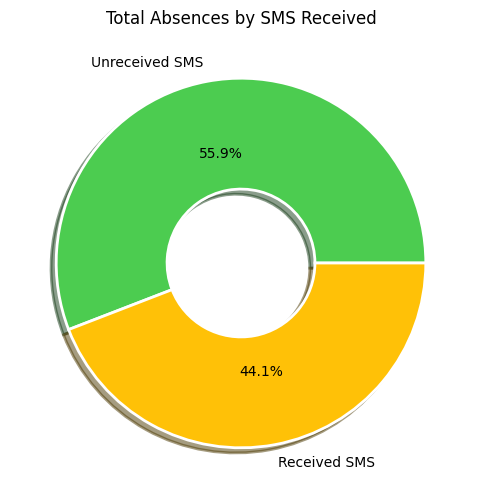

In [33]:
# Total Absences by SMS Received
plt.figure(figsize=(6, 6))
plt.pie(SMS_Absent['AbsentTotal'], labels=['Unreceived SMS','Received SMS'], autopct='%1.1f%%', colors=["#4CCC50", '#FFC107'], shadow=True ,wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2))
plt.title('Total Absences by SMS Received')
plt.show()


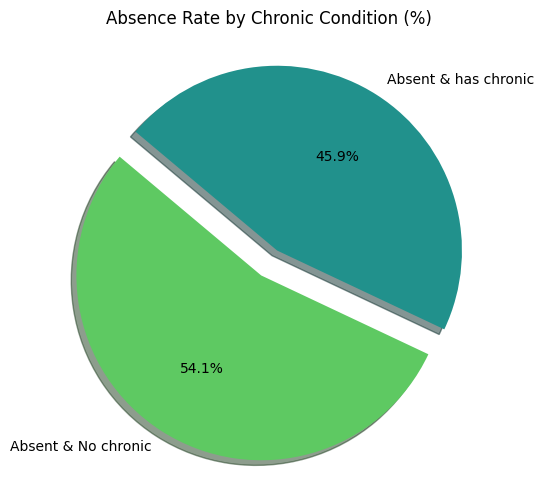

In [34]:
# Absence Rate by Chronic Condition (%)
plt.figure(figsize=(6, 6))
plt.pie(
    Chronic_Absent['Absent'], labels=['Absent & No chronic', 'Absent & has chronic'], autopct='%1.1f%%', startangle=140, colors=['#5ec962',"#21918c"], shadow=True ,explode=(0.08, 0.08)
)


plt.title('Absence Rate by Chronic Condition (%)')
plt.show()

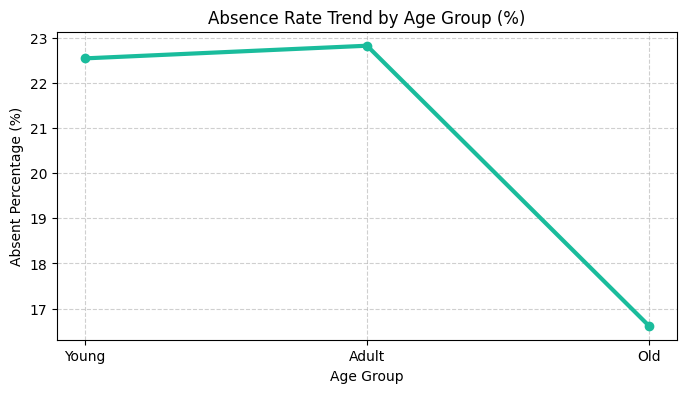

In [35]:
# Absence Rate by Age Group (%)
category_order = ['Young', 'Adult', 'Old']
Age_sorted = Age_absent.set_index('Age_Group').reindex(category_order).reset_index()

plt.figure(figsize=(8, 4))
plt.plot(
    Age_sorted['Age_Group'], 
    Age_sorted['Absent'], 
    marker='o', 
    linewidth=3, 
    color='#1abc9c'
)
plt.title('Absence Rate Trend by Age Group (%)')
plt.xlabel('Age Group')
plt.ylabel('Absent Percentage (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

<a id='conclusions'></a>
## Conclusions

### Summary of Findings
Based on the graphs and data analysis, we found the following:
* **Gender:** Female patients missed more appointments than males, which mostly reflects a higher overall booking rate.

* **Neighborhoods:** Absences are concentrated in specific areas, with *Jardim Camburi* and *Maria Ortiz* having the highest total absences.

* **Scholarships & SMS:** Most missed appointments came from patients without scholarships. Also, patients who did not receive SMS reminders missed more appointments than those who did.

* **Age & Chronic Conditions:** Younger and adult age groups showed higher absence rates compared to older patients, who were more committed to their visits.

### Limitations
Keep in mind a few limitations of this analysis:
* **Correlation, Not Causation:** The findings show patterns and trends, but they do not prove that one factor directly causes another. 

* **Missing Factors:** The dataset does not include external factors like transportation, work hours, or weather, which could also affect attendance.

<a id='recommendations'></a>
## Recommendations

Based on the exploratory data analysis and the patterns observed in the dataset, here are a few actionable recommendations to help healthcare providers improve patient attendance and reduce no-shows:

* **Optimize SMS Reminder Systems:** Since the data shows that patients who did not receive SMS reminders had higher total absences, clinics should ensure that reminder messages are consistently sent to all patients ahead of their scheduled appointments. 

* **Targeted Interventions by Age:** Younger and adult age groups showed higher absence rates compared to older patients. Clinics could design special engagement or confirmation workflows tailored specifically to younger demographics. 

* **Focus on High-Absence Neighborhoods:** Missed appointments were heavily concentrated in specific regions, such as *Jardim Camburi* and *Maria Ortiz*. Healthcare providers could investigate localized barriers in these areas or deploy mobile clinics and targeted outreach. 

* **Further Investigation:** Because this analysis was purely observational, management should consider gathering additional data (such as travel distance, clinic waiting times, or work constraints) to run predictive models and uncover deeper root causes for missed appointments.